# Бейзлайн: логистическая регрессия с полным пайплайном
Цель: быстро проверить общий сигнал по таргету `Рез_экзамена` в полном пайплайне обработки.

## Импорты
Собираем библиотеки в одном месте, чтобы дальше notebook читался по шагам.

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, log_loss, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Пути
Находим корень проекта и задаем путь к данным и папке для метрик.

In [2]:
PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "README.md").exists()
    and (path / "Data_making").is_dir()
    and (path / "Models").is_dir()
)
DATA_PATH = (
    PROJECT_ROOT
    / "Data_making"
    / "synthetic_education_dushanbe_WITH_ROUNDED.csv"
)
METRICS_DIR = PROJECT_ROOT / "Models" / "Compare models"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

## Загрузка данных
Читаем таблицу и смотрим первые строки для быстрой проверки.

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,ID_ученика,Класс,Район,Средний_балл,Часы_самоподготовки_в_неделю,Посещаемость_%,Уверенность_в_себе,Уровень_стресса_перед_экзаменом,Пропущенные_дни,Тип_школы,Рез_экзамена,Индекс_качества_школы,Стабильность_преподавателей,Доступ_к_ресурсам,Образовательная_среда
0,1,11,Исмоили Сомони,3.883,15,81.091,4.0,6.0,8,Обычная школа,1,0.4000,0.2911,0.3107,0.1970
1,2,11,Сино,3.915,15,87.872,4.0,4.0,10,Обычная школа,0,0.4443,0.2559,0.4509,0.5341
2,3,11,Шохмансур,3.660,5,71.282,5.0,6.0,13,Обычная школа,0,0.2499,0.1305,0.1049,0.2666
3,4,11,Исмоили Сомони,4.401,15,84.693,5.0,5.0,10,Обычная школа,1,0.5137,0.5229,0.4238,0.4449
4,5,11,Сино,4.311,12,75.941,5.0,4.0,9,Лицей/гимназия,1,0.4473,0.4858,0.4935,0.4143


## Подготовка признаков
Задаем целевую переменную и общий список признаков для честного сравнения моделей.

In [4]:
TARGET_COL = "Рез_экзамена"
ID_COL = "ID_ученика"
LEAKAGE_RISK_COLS = ["Средний_балл"]

In [5]:
FEATURE_COLUMNS = [
    "Класс",
    "Район",
    "Часы_самоподготовки_в_неделю",
    "Посещаемость_%",
    "Уверенность_в_себе",
    "Уровень_стресса_перед_экзаменом",
    "Пропущенные_дни",
    "Тип_школы",
    "Индекс_качества_школы",
    "Стабильность_преподавателей",
    "Доступ_к_ресурсам",
    "Образовательная_среда",
]

In [6]:
y = df[TARGET_COL]
X = df[FEATURE_COLUMNS].copy()

In [7]:
print('Исключены потенциальные leakage-признаки:', LEAKAGE_RISK_COLS)
print('Форма X после очистки:', X.shape)

Исключены потенциальные leakage-признаки: ['Средний_балл']
Форма X после очистки: (1525, 12)


In [8]:
y.value_counts(normalize=True)

Рез_экзамена
1    0.622295
0    0.377705
Name: proportion, dtype: float64

## Разделение выборки
Делаем единое стратифицированное разделение: train, validation и test.

In [9]:
RANDOM_STATE = 42
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_valid,
)

print('Split sizes:', len(X_train), len(X_valid), len(X_test))

Split sizes: 915 305 305


## Типы признаков
Отделяем категориальные признаки от числовых для препроцессинга.

In [11]:
categorical_features = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(exclude=['object']).columns

## Препроцессинг
Числовые признаки заполняем медианой и стандартизируем. Категориальные заполняем модой и кодируем через OHE.

In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [13]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Модель
Собираем логистическую регрессию и препроцессинг в один pipeline.

In [15]:
model = LogisticRegression(max_iter=500, random_state=RANDOM_STATE, class_weight='balanced')

In [16]:
clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', model)
])

## Обучение
Обучаем pipeline только на train-части.

In [17]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Класс', 'Часы_самоподготовки_в_неделю', 'Посещаемость_%',
       'Уверенность_в_себе', 'Уровень_стресса_перед_экзаменом',
       'Пропущенные_дни', 'Индекс_качества_школы',
       'Стабильность_преподавателей', 'Доступ_к_ресурсам',
       'Образовательная_среда'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Район', 'Тип_школы'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

## Подбор порога
Threshold выбирается только на validation. Test не используется до финальной оценки.

In [18]:
TARGET_MIN_PRECISION = 0.80
threshold_grid = pd.Series([0.1 + 0.005 * i for i in range(161)])
validation_proba = clf.predict_proba(X_valid)[:, 1]

In [19]:
threshold_candidates = []
for threshold in threshold_grid:
    pred = (validation_proba >= threshold).astype(int)
    threshold_candidates.append({
        'threshold': float(threshold),
        'precision': precision_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred, zero_division=0),
        'f1': f1_score(y_valid, pred, zero_division=0),
    })

In [20]:
eligible = [c for c in threshold_candidates if c['precision'] >= TARGET_MIN_PRECISION]
if eligible:
    selected = max(eligible, key=lambda c: c['recall'])
    threshold_strategy = 'max_recall_at_precision_ge_0.80'
    threshold_fallback_used = False
else:
    selected = max(threshold_candidates, key=lambda c: c['f1'])
    threshold_strategy = 'max_f1_fallback'
    threshold_fallback_used = True

In [21]:
final_threshold = selected['threshold']
validation_pred = (validation_proba >= final_threshold).astype(int)

## Финальная оценка
Считаем предсказания и метрики на test с уже выбранным threshold.

In [22]:
test_proba = clf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

In [23]:
print('Selected threshold:', round(final_threshold, 3))
print('Threshold strategy:', threshold_strategy)
print('Test ROC AUC:', roc_auc_score(y_test, test_proba))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('\nTest classification report:\n', classification_report(y_test, test_pred))
print('Test confusion matrix:\n', confusion_matrix(y_test, test_pred))

Selected threshold: 0.535
Threshold strategy: max_recall_at_precision_ge_0.80
Test ROC AUC: 0.8250343249427917
Test Accuracy: 0.7311475409836066

Test classification report:
               precision    recall  f1-score   support

           0       0.61      0.82      0.70       115
           1       0.86      0.68      0.76       190

    accuracy                           0.73       305
   macro avg       0.73      0.75      0.73       305
weighted avg       0.76      0.73      0.74       305

Test confusion matrix:
 [[ 94  21]
 [ 61 129]]


## Кросс-валидация
Проверяем устойчивость ROC AUC на фолдах.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc')
print('CV ROC AUC: %.3f ± %.3f' % (scores.mean(), scores.std()))

CV ROC AUC: 0.762 ± 0.025


## Графики
Показываем основные метрики, ROC-кривую и матрицу ошибок.

In [25]:
metrics = {
    'Accuracy': accuracy_score(y_test, test_pred),
    'ROC AUC': roc_auc_score(y_test, test_proba),
    'Precision': precision_score(y_test, test_pred, zero_division=0),
    'Recall': recall_score(y_test, test_pred, zero_division=0),
    'F1': f1_score(y_test, test_pred, zero_division=0)
}
metrics_df = pd.DataFrame({'metric': list(metrics.keys()), 'value': list(metrics.values())})

In [26]:
fig_m = px.bar(metrics_df, x='metric', y='value', text='value', title='Основные метрики модели')
fig_m.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_m.update_layout(yaxis=dict(range=[0, 1]))
fig_m.show()

In [27]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC'))
fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
fig_roc.update_layout(title='ROC-кривая', xaxis_title='FPR', yaxis_title='TPR')
fig_roc.show()

In [28]:
cm = confusion_matrix(y_test, test_pred)
fig_cm = px.imshow(cm, text_auto=True, aspect='auto',
                   labels=dict(x='Predicted', y='Actual', color='Count'),
                   title='Матрица ошибок')
fig_cm.show()

## SHAP
Интерпретируем линейную модель через SHAP-значения.

In [29]:
preprocess = clf.named_steps['preprocess']
model = clf.named_steps['model']

In [30]:
X_train_t = preprocess.transform(X_train)
feature_names = preprocess.get_feature_names_out()

In [31]:
explainer = shap.LinearExplainer(model, X_train_t, feature_perturbation='interventional')
shap_values = explainer(X_train_t)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning:

The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).



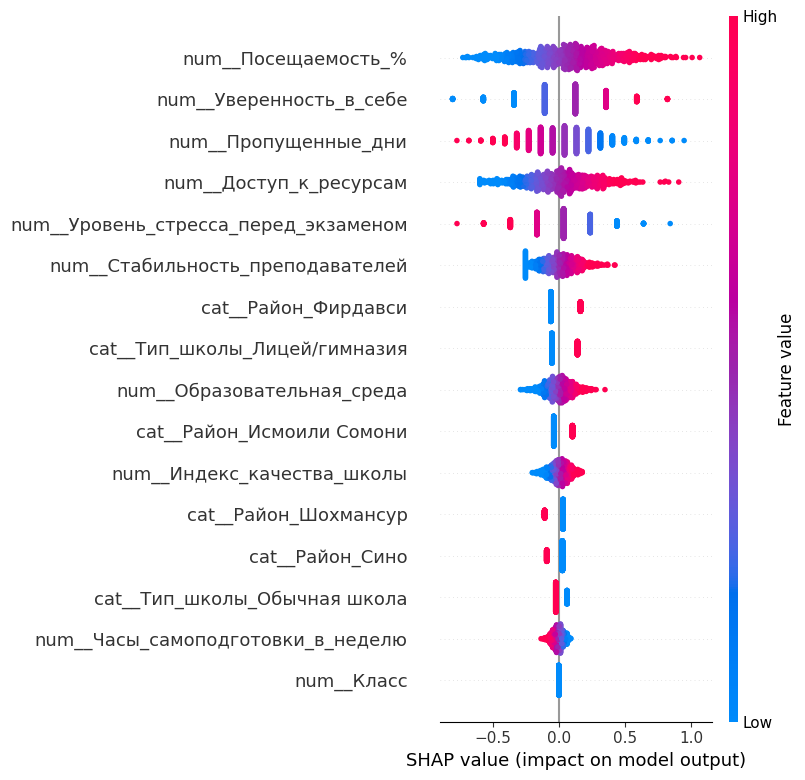

In [32]:
shap.summary_plot(shap_values, features=X_train_t, feature_names=feature_names, show=True)

## Сохранение метрик
Сохраняем итоговые значения для сравнения моделей.

In [33]:
test_tn, test_fp, test_fn, test_tp = confusion_matrix(y_test, test_pred).ravel()

In [34]:
baseline_metrics = {
    'model': 'LogReg',
    'feature_scenario': 'common_no_avg_grade',
    'feature_columns': FEATURE_COLUMNS,
    'excluded_leakage_risk_cols': LEAKAGE_RISK_COLS,
    'split_strategy': 'stratified_train_valid_test',
    'random_state': RANDOM_STATE,
    'train_size': len(X_train),
    'validation_size': len(X_valid),
    'test_size': len(X_test),
    'threshold': float(final_threshold),
    'threshold_strategy': threshold_strategy,
    'threshold_fallback_used': threshold_fallback_used,
    'min_precision_constraint': TARGET_MIN_PRECISION,
}

In [35]:
baseline_metrics.update({
    'validation_ROC_AUC': float(roc_auc_score(y_valid, validation_proba)),
    'validation_PR_AUC': float(average_precision_score(y_valid, validation_proba)),
    'validation_Accuracy': float(accuracy_score(y_valid, validation_pred)),
    'validation_Precision': float(precision_score(y_valid, validation_pred, zero_division=0)),
    'validation_Recall': float(recall_score(y_valid, validation_pred, zero_division=0)),
    'validation_F1': float(f1_score(y_valid, validation_pred, zero_division=0)),
})

In [36]:
baseline_metrics.update({
    'test_ROC_AUC': float(roc_auc_score(y_test, test_proba)),
    'test_PR_AUC': float(average_precision_score(y_test, test_proba)),
    'test_LogLoss': float(log_loss(y_test, test_proba)),
    'test_Accuracy': float(accuracy_score(y_test, test_pred)),
    'test_Precision': float(precision_score(y_test, test_pred, zero_division=0)),
    'test_Recall': float(recall_score(y_test, test_pred, zero_division=0)),
    'test_F1': float(f1_score(y_test, test_pred, zero_division=0)),
    'test_TN': int(test_tn),
    'test_FP': int(test_fp),
    'test_FN': int(test_fn),
    'test_TP': int(test_tp),
})

In [37]:
baseline_metrics.update({
    'CV_AUC_mean': float(scores.mean()),
    'CV_AUC_std': float(scores.std()),
})

In [38]:
out_path = METRICS_DIR / "logreg_metrics.json"
out_path.write_text(json.dumps(baseline_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
print('saved', out_path)

saved /Users/mac/Documents/Portfolio/education-quality-dushanbe/Models/Compare models/logreg_metrics.json


## Выводы
Бейзлайн обучен, оценен на test и сохранен в файл метрик для дальнейшего сравнения.